# Purpose

## Initial exploratory analysis of merged Florida county panel dataset.

# Imports

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Set data paths
PROJECT_ROOT = Path().resolve().parent
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
VISUALS = PROJECT_ROOT / "visuals"

In [3]:
# Import datasets
path = DATA_PROCESSED / "merged_fl_county_year_features.csv"
df = pd.read_csv(path)

# Review Dataset

In [4]:
df.shape

(335, 13)

In [5]:
df.head(10)

,fips,RegionName,year,zhvi_annual,STNAME,CTYNAME,domestic_mig,population,rdomestic_mig,yoy_growth,boom_growth_2020_2022,cooling_delta_2024_vs_2022,yoy_volatility
0,12001,Alachua County,2020,213860.291033,Florida,Alachua County,1315,279765,NaN,NaN,0.319704,-0.125115,0.064152
1,12001,Alachua County,2021,244364.099887,Florida,Alachua County,1142,281710,4.067857,0.142634,0.319704,-0.125115,0.064152
2,12001,Alachua County,2022,282232.292655,Florida,Alachua County,1268,285241,4.473050,0.154966,0.319704,-0.125115,0.064152
3,12001,Alachua County,2023,295677.948240,Florida,Alachua County,408,288962,1.421100,0.047640,0.319704,-0.125115,0.064152
4,12001,Alachua County,2024,304504.265219,Florida,Alachua County,-1141,291782,-3.929442,0.029851,0.319704,-0.125115,0.064152
5,12003,Baker County,2020,214588.831681,Florida,Baker County,-141,28122,NaN,NaN,0.369415,-0.153888,0.094209
6,12003,Baker County,2021,250077.267178,Florida,Baker County,216,28378,7.646018,0.165379,0.369415,-0.153888,0.094209
7,12003,Baker County,2022,293861.137166,Florida,Baker County,-657,27781,-23.397853,0.175081,0.369415,-0.153888,0.094209
8,12003,Baker County,2023,292472.265114,Florida,Baker County,673,28542,23.897875,-0.004726,0.369415,-0.153888,0.094209
9,12003,Baker County,2024,298670.668188,Florida,Baker County,709,29325,24.504467,0.021193,0.369415,-0.153888,0.094209


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335 entries, 0 to 334
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   fips                        335 non-null    int64  
 1   RegionName                  335 non-null    object 
 2   year                        335 non-null    int64  
 3   zhvi_annual                 335 non-null    float64
 4   STNAME                      335 non-null    object 
 5   CTYNAME                     335 non-null    object 
 6   domestic_mig                335 non-null    int64  
 7   population                  335 non-null    int64  
 8   rdomestic_mig               268 non-null    float64
 9   yoy_growth                  268 non-null    float64
 10  boom_growth_2020_2022       335 non-null    float64
 11  cooling_delta_2024_vs_2022  335 non-null    float64
 12  yoy_volatility              335 non-null    float64
dtypes: float64(6), int64(4), object(3)


In [7]:
df.describe()

,fips,year,zhvi_annual,domestic_mig,population,rdomestic_mig,yoy_growth,boom_growth_2020_2022,cooling_delta_2024_vs_2022,yoy_volatility
count,335.000000,335.000000,335.000000,335.000000,3.350000e+02,268.000000,268.000000,335.000000,335.000000,335.000000
mean,12067.910448,2022.000000,295388.149813,2605.140299,3.345683e+05,17.761734,0.118410,0.454965,-0.205427,0.106437
std,38.453149,1.416329,126538.596005,8713.754741,5.101238e+05,19.210338,0.096692,0.076199,0.070643,0.027820
min,12001.000000,2020.000000,114008.840668,-67418.000000,7.294000e+03,-56.688742,-0.043954,0.236375,-0.357226,0.041724
25%,12035.000000,2021.000000,204521.558502,150.000000,2.806600e+04,5.530396,0.029737,0.391883,-0.263433,0.089315
50%,12069.000000,2022.000000,275839.758432,1022.000000,1.449780e+05,19.352730,0.104084,0.445698,-0.198414,0.106300
75%,12101.000000,2023.000000,360323.900709,5031.000000,4.070600e+05,31.384359,0.200581,0.514185,-0.144709,0.127275
max,12133.000000,2024.000000,993480.728374,29407.000000,2.838461e+06,81.297385,0.357356,0.618030,-0.080988,0.167312


# Distribution of YoY Growth

In [8]:
# Convert decimal to percentage for chart clarity
df["yoy_growth_percent"] = df["yoy_growth"] * 100

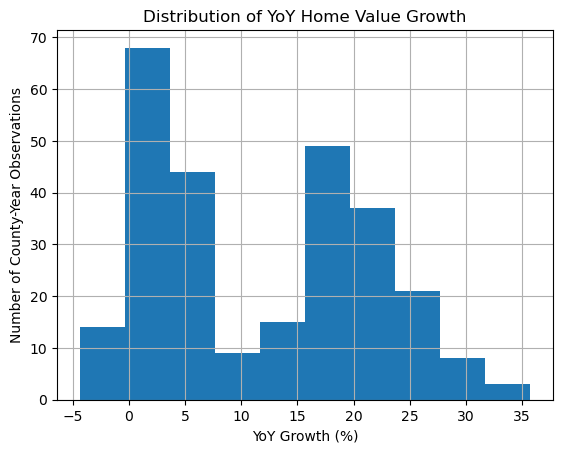

In [9]:
# Create histogram and set titles
plt.figure() # Creates new blank canvas. Necessary for multi-plot notebooks
df["yoy_growth_percent"].hist()
plt.title("Distribution of YoY Home Value Growth")
plt.xlabel("YoY Growth (%)")
plt.ylabel("Number of County-Year Observations")
plt.savefig(VISUALS/"yoy_growth_distribution.png", bbox_inches="tight") # Export visual
plt.show()

# Distribution of Domestic Migration Rate

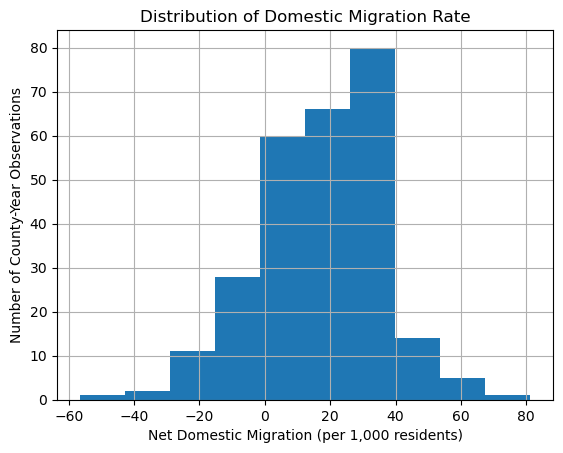

In [10]:
# Create histogram and set titles
plt.figure()
df["rdomestic_mig"].hist()
plt.title("Distribution of Domestic Migration Rate")
plt.xlabel("Net Domestic Migration (per 1,000 residents)")
plt.ylabel("Number of County-Year Observations")
plt.savefig(VISUALS/"domestic_migration_distribution.png", bbox_inches="tight") # Export
plt.show()

# Migration vs Growth

## 2021-2024 (All data)

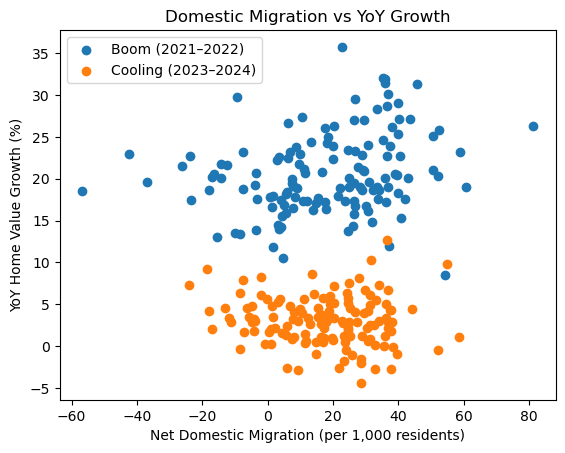

In [11]:
plt.figure()

# Boom
boom = df[df["year"].isin([2021, 2022])]
plt.scatter(boom["rdomestic_mig"], boom["yoy_growth_percent"], label="Boom (2021–2022)")

# Cooling
cooling = df[df["year"].isin([2023, 2024])]
plt.scatter(cooling["rdomestic_mig"], cooling["yoy_growth_percent"], label="Cooling (2023–2024)")

plt.title("Domestic Migration vs YoY Growth")
plt.xlabel("Net Domestic Migration (per 1,000 residents)")
plt.ylabel("YoY Home Value Growth (%)")
plt.legend()

plt.savefig(VISUALS / "migration_vs_growth_colored.png", bbox_inches="tight")
plt.show()

In [12]:
# Check correlation
df[["yoy_growth", "rdomestic_mig"]].corr()

,yoy_growth,rdomestic_mig
yoy_growth,1.000000,0.068413
rdomestic_mig,0.068413,1.000000


## 2021–2022 (boom)

In [13]:
# Create subset
df_boom = df[df["year"].isin([2021, 2022])]

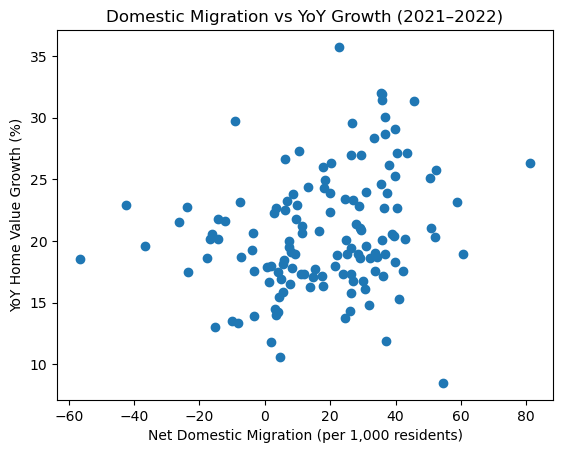

In [14]:
# Create scatterplot and set titles
plt.figure()
plt.scatter(df_boom["rdomestic_mig"], df_boom["yoy_growth_percent"])
plt.title("Domestic Migration vs YoY Growth (2021–2022)")
plt.xlabel("Net Domestic Migration (per 1,000 residents)")
plt.ylabel("YoY Home Value Growth (%)")
plt.savefig(VISUALS/"migration_vs_growth_boom.png", bbox_inches="tight") # Export
plt.show()

In [15]:
# Check correlation
df_boom[["yoy_growth", "rdomestic_mig"]].corr()

,yoy_growth,rdomestic_mig
yoy_growth,1.000000,0.242514
rdomestic_mig,0.242514,1.000000


## 2023–2024 (cooling)

In [16]:
# Create subset
df_cooling = df[df["year"].isin([2023, 2024])]

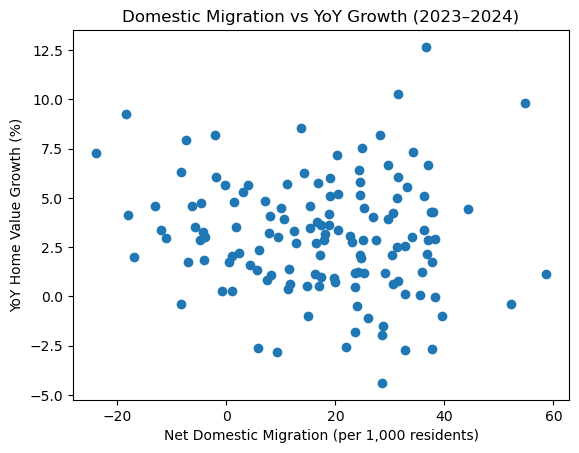

In [17]:
# Create scatterplot and set titles
plt.figure()
plt.scatter(df_cooling["rdomestic_mig"], df_cooling["yoy_growth_percent"])
plt.title("Domestic Migration vs YoY Growth (2023–2024)")
plt.xlabel("Net Domestic Migration (per 1,000 residents)")
plt.ylabel("YoY Home Value Growth (%)")
plt.savefig(VISUALS/"migration_vs_growth_cooling.png", bbox_inches="tight") # Export
plt.show()

In [18]:
# Check correlation
df_cooling[["yoy_growth", "rdomestic_mig"]].corr()

,yoy_growth,rdomestic_mig
yoy_growth,1.000000,-0.103233
rdomestic_mig,-0.103233,1.000000
